# Bandas espectrais não-visíveis melhoram a classificação de uso do solo?
## Um estudo com EuroSAT (Sentinel-2) e CNNs

---

### Objetivo
Avaliar **quantitativamente** se bandas espectrais além do visível — infravermelho próximo (NIR) e de ondas curtas (SWIR) — melhoram a classificação de uso/cobertura do solo.

### Hipótese
> Bandas não-visíveis (NIR e SWIR) melhoram significativamente a classificação em relação a apenas RGB, especialmente para vegetação e água.

### Metodologia
Treinamos **a mesma CNN** três vezes, mudando apenas os canais de entrada:

| Modelo | Bandas | Canais |
|--------|--------|--------|
| **A — RGB** | B4, B3, B2 | 3 |
| **B — RGB + NIR** | B4, B3, B2, B8 | 4 |
| **C — Multi-espectral** | todas | 13 |

Mesma seed, mesmo split (70/15/15), mesma normalização, mesmos callbacks. A única variável é o conjunto de bandas → comparação justa.

> Este notebook **não treina nada**: carrega os resultados salvos em `results/` pelos notebooks 03–05.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

from src import config, evaluation
from src import visualization as viz

MODELS = {
    'A — RGB': 'model_a_rgb',
    'B — RGB+NIR': 'model_b_rgb_nir',
    'C — Multi-espectral': 'model_c_multispectral',
}

metrics = {label: evaluation.load_metrics(config.METRICS_DIR / f'{name}.json') for label, name in MODELS.items()}
histories = {label: json.loads((config.HISTORIES_DIR / f'{name}.json').read_text()) for label, name in MODELS.items()}
print('Resultados carregados:', list(metrics))

Resultados carregados: ['A — RGB', 'B — RGB+NIR', 'C — Multi-espectral']


## 1. Tabela comparativa

In [2]:
table = viz.build_comparison_table(metrics)
table

,Modelo,Acurácia,F1 macro,Tempo treino (s),Parâmetros
0,A — RGB,0.9820,0.9813,246.6,289642
1,B — RGB+NIR,0.9805,0.9795,223.6,289930
2,C — Multi-espectral,0.9862,0.9852,1076.7,292522


## 2. Curvas de validação lado a lado

Quão rápido e quão alto cada modelo converge.

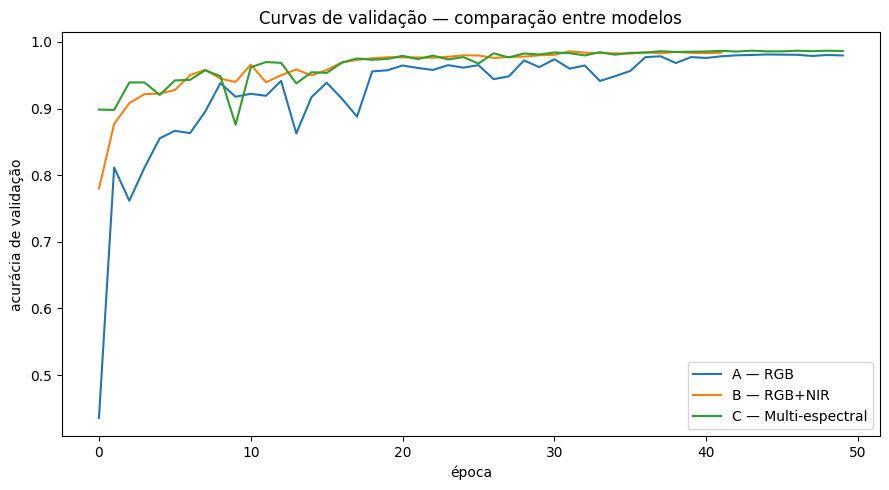

In [3]:
viz.plot_curves_side_by_side(histories, save_path=config.FIGURES_DIR / 'comparison_curves.png')
plt.show()

## 3. Acurácia no teste — comparação direta

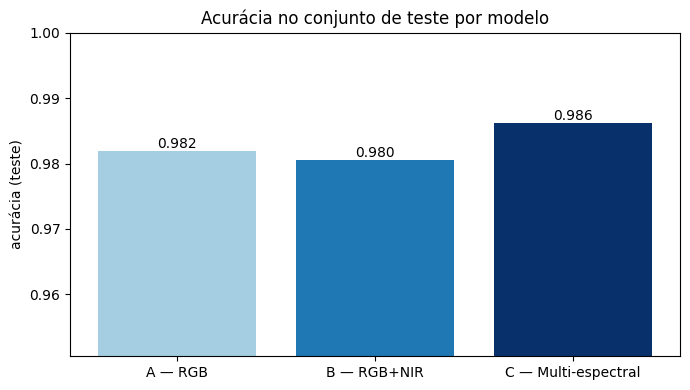

In [4]:
accs = [metrics[k]['accuracy'] for k in MODELS]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(MODELS), accs, color=['#a6cee3', '#1f78b4', '#08306b'])
ax.set_ylabel('acurácia (teste)'); ax.set_ylim(min(accs) - 0.03, 1.0)
ax.set_title('Acurácia no conjunto de teste por modelo')
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a, f'{a:.3f}', ha='center', va='bottom')
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / 'comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Matrizes de confusão lado a lado

Normalizadas por linha (mostram a taxa de acerto/erro por classe real).

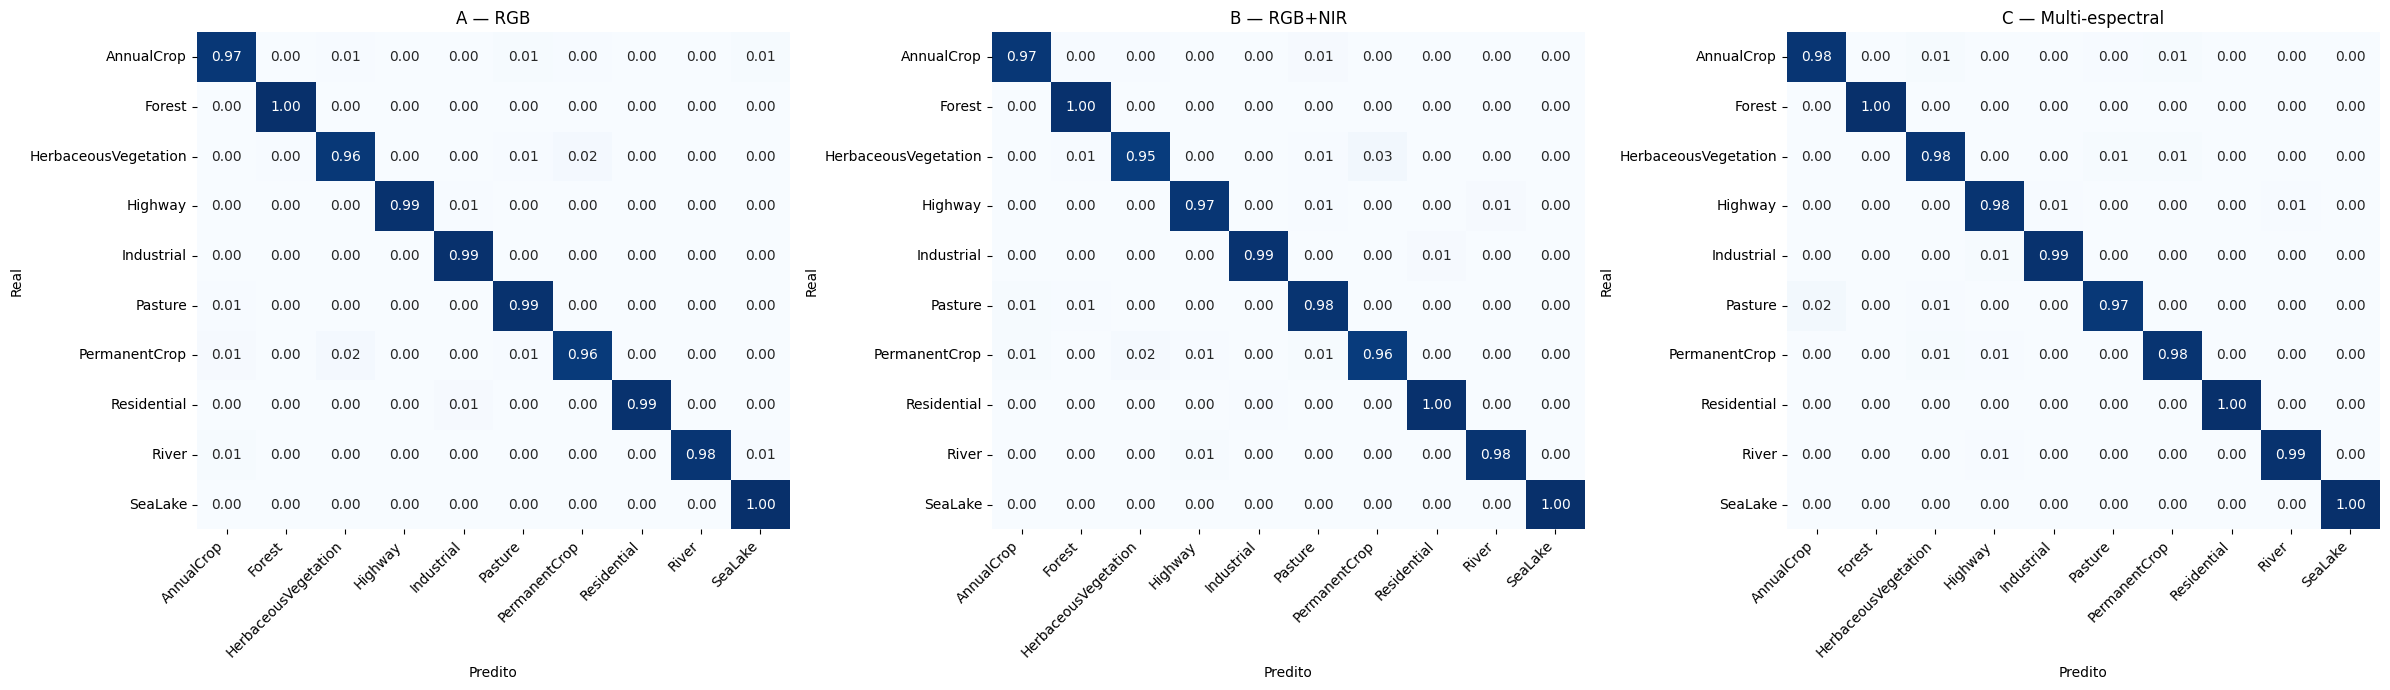

In [5]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (label, m) in zip(axes, metrics.items()):
    cm, _ = evaluation.compute_confusion_matrix(m['y_true'], m['y_pred'])
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=config.CLASS_NAMES, yticklabels=config.CLASS_NAMES, ax=ax)
    ax.set_title(label); ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / 'comparison_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. F1 por classe — quem se beneficia das bandas extras?

Esperamos ganho maior em vegetação (NIR) e água/sombra (SWIR).

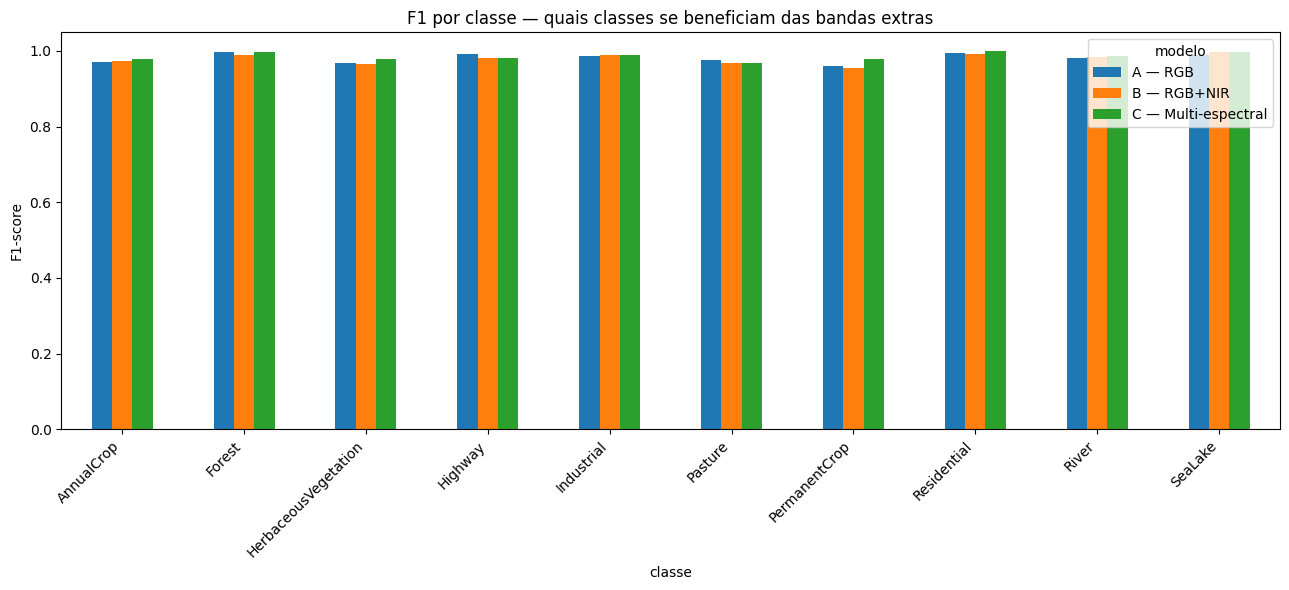

,A (RGB),C (13 bandas),Ganho (C - A)
PermanentCrop,0.960674,0.979021,0.0183
HerbaceousVegetation,0.968182,0.977376,0.0092
SeaLake,0.989429,0.997868,0.0084
AnnualCrop,0.971765,0.977726,0.0060
River,0.980556,0.986188,0.0056
Residential,0.993318,0.998893,0.0056
Industrial,0.985185,0.990050,0.0049
Forest,0.995633,0.995643,0.0000
Pasture,0.976109,0.968750,-0.0074
Highway,0.992327,0.980892,-0.0114


In [6]:
viz.plot_per_class_comparison(metrics, save_path=config.FIGURES_DIR / 'comparison_per_class.png')
plt.show()

# Ganho de F1 por classe: Modelo C menos Modelo A.
delta = pd.DataFrame({
    'A (RGB)': metrics['A — RGB']['f1_per_class'],
    'C (13 bandas)': metrics['C — Multi-espectral']['f1_per_class'],
})
delta['Ganho (C - A)'] = (delta['C (13 bandas)'] - delta['A (RGB)']).round(4)
delta.sort_values('Ganho (C - A)', ascending=False)

## 6. Por que o NIR ajuda — análise via NDVI

O NDVI = (B8 − B4) / (B8 + B4) usa uma banda não-visível (B8) para separar vegetação de construção. É a intuição física por trás de qualquer ganho dos modelos B e C.

I0000 00:00:1780163609.949572   12314 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780163615.816544   12314 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6
I0000 00:00:1780163616.172288   12400 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


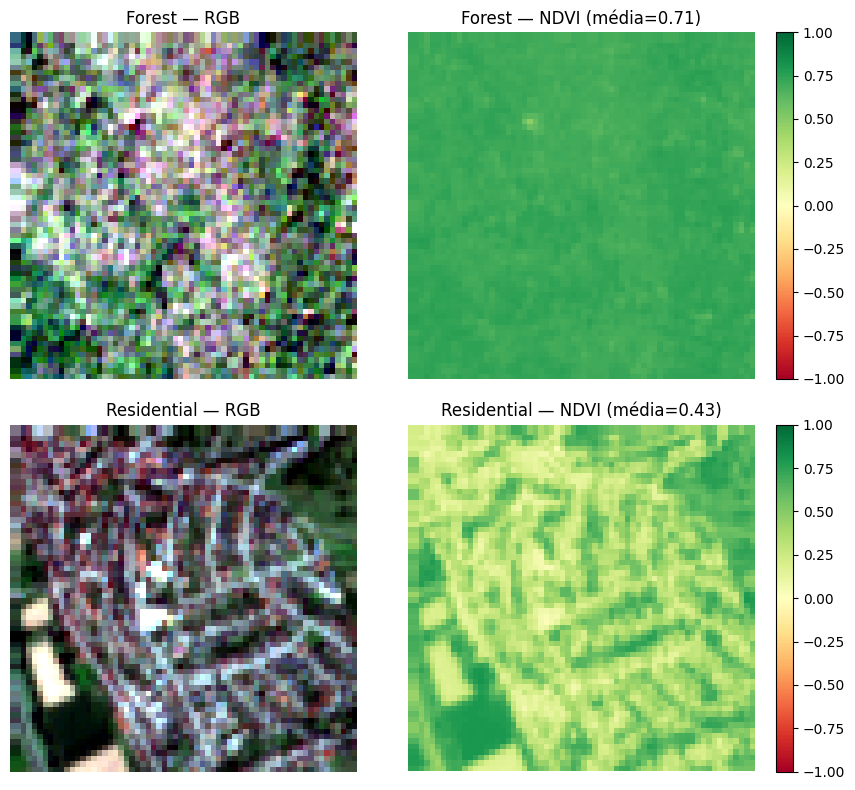

In [7]:
ds = tfds.load(config.DATASET_NAME, split='train', shuffle_files=False)
samples = {}
for ex in ds:
    lbl = int(ex[config.LABEL_KEY])
    if lbl not in samples:
        samples[lbl] = ex[config.IMAGE_KEY].numpy()
    if len(samples) == config.NUM_CLASSES:
        break

forest = samples[config.CLASS_NAMES.index('Forest')]
resid = samples[config.CLASS_NAMES.index('Residential')]
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for row, (img, name) in enumerate([(forest, 'Forest'), (resid, 'Residential')]):
    ndvi = viz.compute_ndvi(img)
    axes[row, 0].imshow(viz.rgb_composite(img)); axes[row, 0].set_title(f'{name} — RGB'); axes[row, 0].axis('off')
    im = axes[row, 1].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[row, 1].set_title(f'{name} — NDVI (média={ndvi.mean():.2f})'); axes[row, 1].axis('off')
    fig.colorbar(im, ax=axes[row, 1], fraction=0.046)
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / 'ndvi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusão

**Resultado principal.** Os três modelos superaram com folga a meta de 85%, atingindo no conjunto de teste:

| Modelo | Acurácia | F1 macro |
|--------|----------|----------|
| A — RGB | 98,20% | 0,9813 |
| B — RGB+NIR | 98,05% | 0,9795 |
| C — Multi-espectral | **98,62%** | **0,9852** |

A ordem observada foi **C > A > B**. O modelo com **todas as 13 bandas foi o melhor**, confirmando a hipótese de que bandas não-visíveis agregam informação útil — porém o ganho sobre o RGB puro foi **pequeno: +0,42 ponto percentual de acurácia** (+0,39 em F1 macro).

**Um achado honesto:** adicionar **apenas o NIR** (modelo B) **não ajudou** — ficou inclusive levemente abaixo do RGB (98,05% vs 98,20%), dentro da margem de ruído de uma única seed. Ou seja, não houve o ganho monotônico A < B < C que se poderia esperar; o benefício só apareceu de forma consistente ao usar o **conjunto completo** de bandas (incluindo red-edge B5–B7 e SWIR B11–B12), não o NIR isolado.

**Onde as bandas extras ajudaram** (ganho de F1 por classe, C − A):
- **PermanentCrop +0,018** — culturas permanentes (pomares/vinhedos), difíceis de separar só no visível, têm assinatura espectral distinta.
- **HerbaceousVegetation +0,009** e **AnnualCrop +0,006** — tipos de vegetação.
- **SeaLake +0,008** — água, onde o SWIR dá bom contraste.

São justamente classes de **vegetação e água** — coerente com a hipótese e com a física do NDVI. Em contrapartida, **Highway (−0,011)** e **Pasture (−0,007)** pioraram um pouco, e **Forest** já estava saturada (F1 ≈ 0,996 nos dois modelos), sem espaço para melhora.

**Custo.** O nº de parâmetros quase não muda (290k → 293k; só a 1ª camada cresce). Já o **tempo de treino foi ~4× maior** no modelo C (≈18 min vs ≈4 min), pelo volume de dados (13 bandas) lido a cada época.

**Interpretação geral.** No EuroSAT, o **RGB sozinho já resolve ~98%** do problema — esse teto alto deixa pouca margem para as bandas extras brilharem. Elas trazem ganho real, mas modesto, concentrado em classes de vegetação/água. Num problema mais difícil (mais classes, mais confusão espectral), é razoável esperar uma vantagem maior do multi-espectral.

### Limitações
- Resultados de **uma única seed** — as diferenças de ~0,4 pp estão na ordem do ruído de treino; o ideal é repetir com várias seeds.
- EuroSAT é relativamente "fácil" e bem balanceado; o teto de acurácia alto **mascara** diferenças entre os modelos.
- Imagens 64×64 já pré-recortadas por classe — não reflete um cenário de segmentação real.

### Trabalhos futuros
- Rodar com **3+ seeds** e reportar média ± desvio (com teste estatístico) para confirmar se C > A é significativo.
- Adicionar **índices derivados** (NDVI, NDWI, NDBI) como canais extras de entrada.
- Testar **arquiteturas maiores** ou transfer learning, e datasets mais desafiadores.